# 4. Análisis de la variable objetivo (sección 2.1)

*Autores: María Carolina Cantillo Orozco (200179105) y Juan Camilo Oñoro Araujo (200177329)*

Variable objetivo: `estrato_num` (1 a 6), categórica **ordinal**. Todo el
análisis usa **solo entrenamiento**.

In [1]:
# Configuración y carga de SOLO entrenamiento: el análisis del objetivo alimenta
# decisiones (métrica principal, tratamiento del desbalance), así que no puede
# usar test sin generar fuga de información.
import sys
import warnings
from pathlib import Path

# Raíz del libro en sys.path para importar src/ desde notebooks/ o desde la raíz.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src import config as C       # OBJETIVO, CLASES, NOMBRES_CLASES, SEED
from src import estadistica as E  # entropía de la distribución de clases
from src import graficos as G     # estilo, paleta ordinal del estrato y ejes de mapa
from src import particion as P

G.estilo()
C.aviso_sintetico()
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
train = P.cargar_particion(solo="train")   # filas con particion == "train"

## 4.1 Frecuencia de cada clase y desbalance

In [2]:
# Frecuencia de cada estrato en train y medidas de desbalance. Definen si hace falta
# remuestrear (SMOTE) y qué métrica usar: con clases desiguales el accuracy premia
# a la mayoritaria, por eso se calcula también el accuracy del clasificador trivial.
frec = train[C.OBJETIVO].value_counts().sort_index().rename("casos").to_frame()
frec["%"] = 100 * frec["casos"] / frec["casos"].sum()
frec["% acumulado"] = frec["%"].cumsum()    # útil por ser ordinal: "% hasta el estrato k"
frec.index = [C.NOMBRES_CLASES[i] for i in frec.index]
# Razón de desbalance: casos de la clase más frecuente / casos de la menos frecuente.
razon = frec["casos"].max() / frec["casos"].min()
# Entropía de Shannon (logaritmo natural). Al dividirla por log(6), su máximo con
# 6 clases, queda entre 0 (una sola clase) y 1 (las 6 clases igual de frecuentes).
H = E.entropia(train[C.OBJETIVO])
print(f"Clase mayoritaria: {frec['casos'].idxmax()} ({frec['%'].max():.1f}%)")
print(f"Clase minoritaria: {frec['casos'].idxmin()} con {frec['casos'].min():,} casos ({frec['%'].min():.1f}%)")
print(f"Razón de desbalance (mayor/menor): {razon:.1f} : 1")
print(f"Entropía normalizada H/log(6) = {H / np.log(6):.3f}  (1 = clases perfectamente balanceadas)")
# Piso de referencia: lo que acierta un DummyClassifier que siempre dice la mayoritaria.
print(f"Accuracy de predecir siempre la mayoritaria: {frec['%'].max():.1f}%")
frec

Clase mayoritaria: 3 Medio-bajo (26.0%)
Clase minoritaria: 6 Alto con 12,390 casos (5.7%)
Razón de desbalance (mayor/menor): 4.6 : 1
Entropía normalizada H/log(6) = 0.923  (1 = clases perfectamente balanceadas)
Accuracy de predecir siempre la mayoritaria: 26.0%


,casos,%,% acumulado
1 Bajo-bajo,55904,25.542,25.542
2 Bajo,43480,19.866,45.408
3 Medio-bajo,56871,25.984,71.392
4 Medio,36894,16.857,88.248
5 Medio-alto,13331,6.091,94.339
6 Alto,12390,5.661,100.000


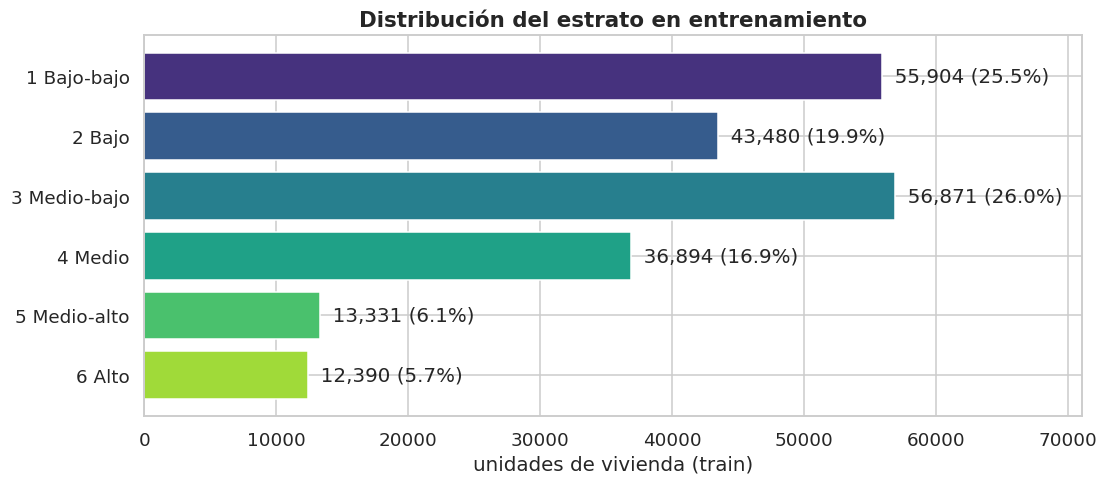

In [3]:
# Barras horizontales con los casos de cada estrato en train y su porcentaje.
# Muestra el desbalance: estratos 5 y 6 son claramente minoritarios.
fig, ax = plt.subplots(figsize=(11, 4.5))
# Paleta viridis ordinal (claro = bajo, oscuro = alto), la misma en todo el libro.
colores = [G.PALETA_ESTRATO[c] for c in C.CLASES]
# Orden invertido para que el estrato 1 quede arriba.
ax.barh(frec.index[::-1], frec["casos"][::-1], color=colores[::-1])
# Etiqueta "casos (%)" al final de cada barra.
for i, (n, p) in enumerate(zip(frec["casos"][::-1], frec["%"][::-1])):
    ax.text(n, i, f"  {n:,} ({p:.1f}%)", va="center")
ax.set_xlim(0, frec["casos"].max() * 1.25)   # margen para que quepan las etiquetas
ax.set_xlabel("unidades de vivienda (train)")
ax.set_title("Distribución del estrato en entrenamiento")
G.guardar(fig, "04_distribucion_objetivo")
plt.show()

```{admonition} Interpretación
:class: note
- En train la clase más frecuente es el **estrato 3 (26.0 %)**, muy cerca
  del 1 (25.5 %); luego 2 (19.9 %), 4 (16.9 %), 5 (6.1 %) y 6 (5.7 %). En el
  dataset completo el 1 es mayoritario (32.8 %, cap. 1): la diferencia se debe
  a que train excluye las filas sin coordenadas (66 % de ellas son estrato 1,
  cap. 3) y los bloques de test.
- El desbalance es **moderado: 4.6 : 1**, y la entropía normalizada es 0.92
  (1 sería balance perfecto). La clase minoritaria (estrato 6) tiene
  **12 390 casos**, así que **no hace falta sobremuestreo (SMOTE)** para que
  el modelo vea suficientes ejemplos; lo que sí cambia el desbalance es
  **cómo se evalúa**: un modelo trivial que siempre dice "estrato 3" ya
  acierta 26 %, así que el accuracy solo no sirve.
```

## 4.2 Naturaleza ordinal

Confundir un estrato 5 con un 6 no es tan grave como confundir un 1 con un
6. Las métricas estándar de clasificación tratan ambos errores igual; por eso
se añaden métricas ordinales: **MAE en la escala de estratos**, **accuracy
±1** y **kappa de Cohen con pesos cuadráticos**.

## 4.3 Comportamiento en el espacio

El dataset no tiene tiempo (es una foto del catastro), pero sí espacio. Mapa
del estrato en entrenamiento (puntos y promedio por celda de 500 m):

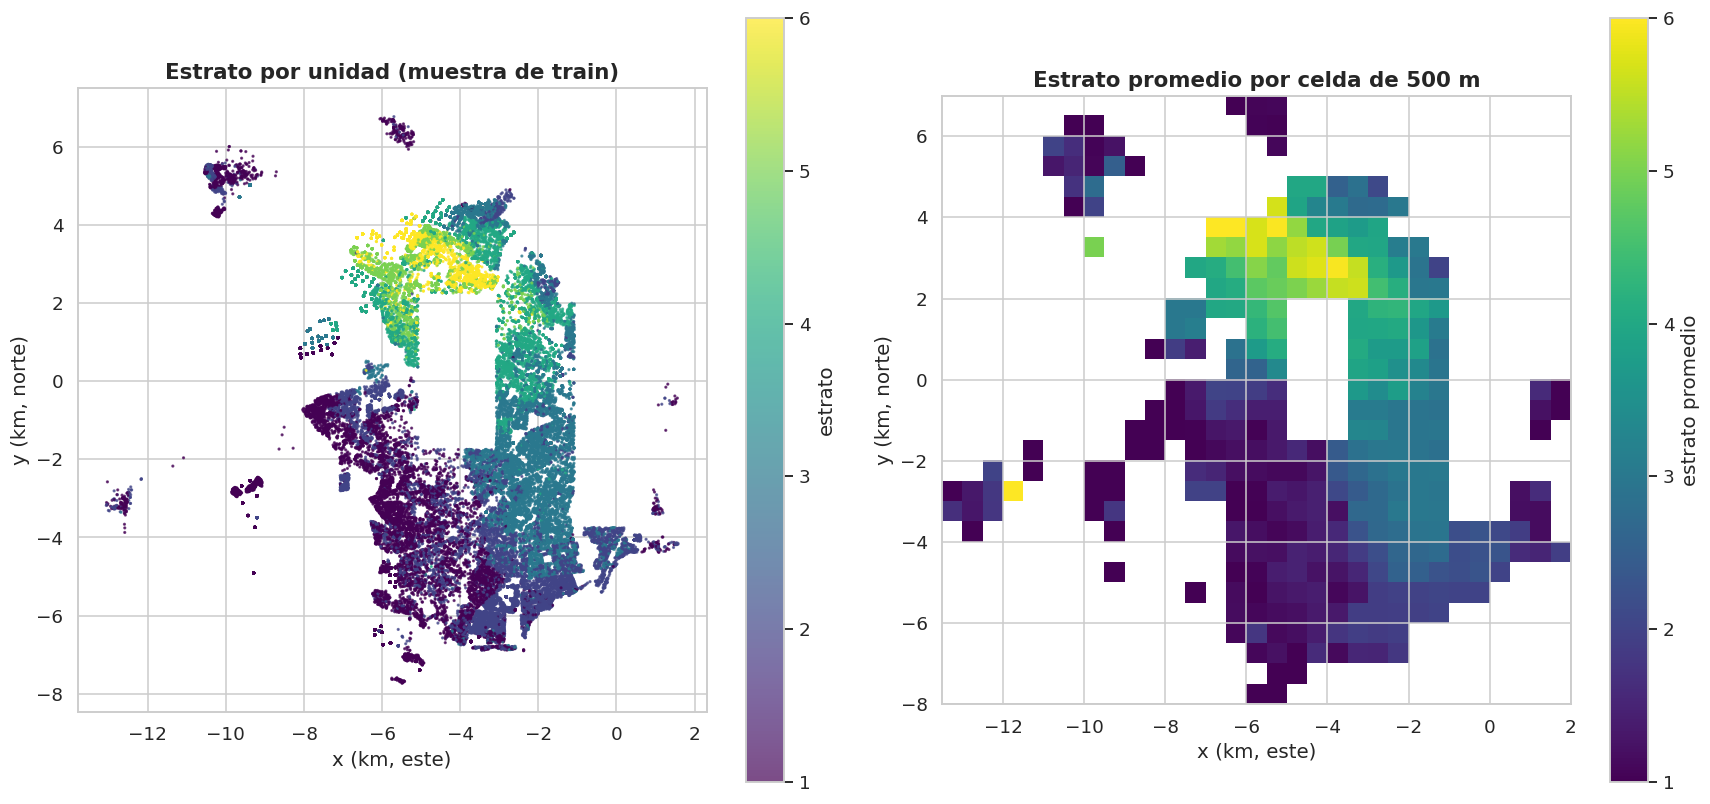

In [4]:
# Mapas del estrato en train. Izquierda: cada punto es una unidad (muestra de
# 50 000 con semilla fija para dibujar rápido). Derecha: estrato promedio por
# celda de 500 m, que agrega los puntos (menos ruido y sin exponer predios
# individuales, consideración ética 1.8) y deja ver el gradiente sur-norte.
m = train.sample(min(50_000, len(train)), random_state=C.SEED)
fig, axes = plt.subplots(1, 2, figsize=(16, 7.5))
sc = axes[0].scatter(m["x_km"], m["y_km"], c=m[C.OBJETIVO], cmap="viridis", s=1.2, alpha=0.7, rasterized=True)
G.ejes_mapa(axes[0], "Estrato por unidad (muestra de train)")
plt.colorbar(sc, ax=axes[0], label="estrato")
celda = 0.5   # lado de la celda en km (500 m)
# Índice de celda = floor(coordenada / celda); se promedia el estrato en cada celda
# (usando TODO train, no la muestra) y se pasa a matriz filas = cy, columnas = cx.
g = train.assign(cx=np.floor(train.x_km / celda), cy=np.floor(train.y_km / celda)) \
         .groupby(["cy", "cx"])[C.OBJETIVO].mean().unstack()
g = g.reindex(index=np.arange(g.index.min(), g.index.max() + 1),
              columns=np.arange(g.columns.min(), g.columns.max() + 1))  # grilla completa
# origin="lower" pone el sur abajo; extent convierte índices de celda a km para que
# los ejes coincidan con el mapa de puntos. vmin/vmax fijan la escala en 1-6.
# Las celdas sin viviendas quedan NaN y se ven en blanco.
im = axes[1].imshow(g.to_numpy(), origin="lower", cmap="viridis", vmin=1, vmax=6,
                    extent=[g.columns.min() * celda, (g.columns.max() + 1) * celda,
                            g.index.min() * celda, (g.index.max() + 1) * celda])
G.ejes_mapa(axes[1], "Estrato promedio por celda de 500 m")
plt.colorbar(im, ax=axes[1], label="estrato promedio")
fig.tight_layout()
G.guardar(fig, "04_mapa_objetivo")
plt.show()

In [5]:
# Cuantificación del gradiente norte-sur visto en el mapa: se divide train en 5
# franjas de igual número de filas según y_km (quintiles, pd.qcut) y se calcula la
# composición de estratos (% por fila) y el estrato medio de cada franja.
por_franja = train.assign(franja_norte_sur=pd.qcut(train["y_km"], 5, labels=["sur", "centro-sur", "centro",
                                                                              "centro-norte", "norte"]))
tabla = pd.crosstab(por_franja["franja_norte_sur"], por_franja[C.OBJETIVO], normalize="index").mul(100)
tabla.columns = [C.NOMBRES_CLASES[c] for c in tabla.columns]
# observed=True: agrupa solo por las categorías presentes (qcut crea un Categorical).
tabla["estrato medio"] = por_franja.groupby("franja_norte_sur", observed=True)[C.OBJETIVO].mean()
tabla

,1 Bajo-bajo,2 Bajo,3 Medio-bajo,4 Medio,5 Medio-alto,6 Alto,estrato medio
franja_norte_sur,,,,,,,
sur,49.198,46.783,3.941,0.075,0.000,0.002,1.549
centro-sur,36.300,30.027,33.534,0.123,0.002,0.014,1.975
centro,26.843,16.259,44.244,12.552,0.097,0.005,2.428
centro-norte,8.210,1.817,27.450,41.729,12.870,7.924,3.730
norte,7.008,4.325,20.614,30.039,17.589,20.426,4.082


```{admonition} Interpretación del gradiente espacial
:class: note
El estrato medio sube de forma casi monótona de sur a norte: **1.55** en la
franja sur, 1.98 en centro-sur, 2.43 en el centro, **3.73** en centro-norte
y **4.08** en el norte. En el sur, el 96 % de las unidades son estratos 1–2
y prácticamente no hay estratos 5–6; en el norte, el 38 % son 5–6. El salto
más grande ocurre entre el centro y el centro-norte (+1.3 estratos). Es la
señal espacial más fuerte del EDA y reaparece en el cap. 6 (`y_km` es la
variable más asociada con el estrato) y en el cap. 8 (Moran's I ≈ 0.9).
```

```{admonition} Implicaciones para la métrica y la validación
:class: important
1. **Métrica principal: F1 macro** (promedia las 6 clases por igual, así los
   estratos 5 y 6 pesan lo mismo que el 1). Se reportan además balanced
   accuracy, AUC one-vs-rest macro, matriz de confusión y, por ser ordinal,
   MAE ordinal y kappa cuadrático (notas de clase 9.5).
2. **Línea base:** `DummyClassifier` (mayoritaria, estratificada, uniforme)
   y una línea base espacial (clase más frecuente por zona).
3. **Validación:** el estrato cambia de forma muy marcada en el espacio
   (estrato medio 4.1 en el norte frente a 1.5 en el sur), así que una validación
   aleatoria sería optimista: se usa validación **por bloques espaciales
   estratificada** (capítulo 2) con buffer (capítulo 8).
4. **Desbalance:** se compara `class_weight=None` contra `"balanced"` dentro
   de la búsqueda de hiperparámetros (capítulo 10).
```

In [6]:
# Se registran las decisiones de evaluación derivadas de este capítulo: F1 macro
# como métrica principal (por el desbalance, pesa igual cada estrato) y métricas
# ordinales (MAE, accuracy ±1, kappa cuadrático) porque errar por 5 estratos es
# peor que errar por 1. El modelo base (cap. 10) lee estas decisiones del JSON.
C.guardar_decision("metrica_principal", "f1_macro",
                   f"Desbalance {razon:.1f}:1 y 6 clases (cap. 4.1): el accuracy premia a la clase mayoritaria.")
C.guardar_decision("metricas_ordinales", ["MAE_ordinal", "accuracy_±1", "kappa_cuadrático"],
                   "El estrato es ordinal (cap. 4.2): errores lejanos deben pesar más.")

[decisión registrada] metrica_principal = f1_macro
   motivo: Desbalance 4.6:1 y 6 clases (cap. 4.1): el accuracy premia a la clase mayoritaria.
[decisión registrada] metricas_ordinales = ['MAE_ordinal', 'accuracy_±1', 'kappa_cuadrático']
   motivo: El estrato es ordinal (cap. 4.2): errores lejanos deben pesar más.
